In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:

boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
df = boston.data.copy()
df['MEDV'] = pd.to_numeric(boston.target)

df = df.apply(pd.to_numeric)
print('ابعاد دیتاست:', df.shape)
df.head()

ابعاد دیتاست: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
correlations = df.corr(numeric_only=True)['MEDV'].drop('MEDV').sort_values(key=abs, ascending=False)
print(correlations)

features = ['RM', 'LSTAT']
X = df[features].to_numpy(dtype=float)
y = df['MEDV'].to_numpy(dtype=float).reshape(-1, 1)

LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)
y_train_s = y_scaler.fit_transform(y_train)

print('تعداد نمونه‌های آموزش:', len(X_train))
print('تعداد نمونه‌های آزمون:', len(X_test))

تعداد نمونه‌های آموزش: 404
تعداد نمونه‌های آزمون: 102


In [5]:
class RegressionPerceptron:
    def __init__(self, learning_rate=0.05, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0.0

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            dw = (2 / n_samples) * X.T @ error
            db = (2 / n_samples) * np.sum(error)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

In [6]:
model = RegressionPerceptron(learning_rate=0.05, epochs=1000)
model.fit(X_train_s, y_train_s)

y_pred_s = model.predict(X_test_s)
y_pred = y_scaler.inverse_transform(y_pred_s)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE  = {mse:.3f}')
print(f'RMSE = {rmse:.3f}')
print(f'MAE  = {mae:.3f}')
print(f'R²   = {r2:.3f}')
print('Weights (standardized):', model.weights.ravel())
print('Bias (standardized):', model.bias)

MSE  = 31.243
RMSE = 5.590
MAE  = 3.899
R²   = 0.574
Weights (standardized): [ 0.41546965 -0.48191544]
Bias (standardized): 1.9149698328707493e-15


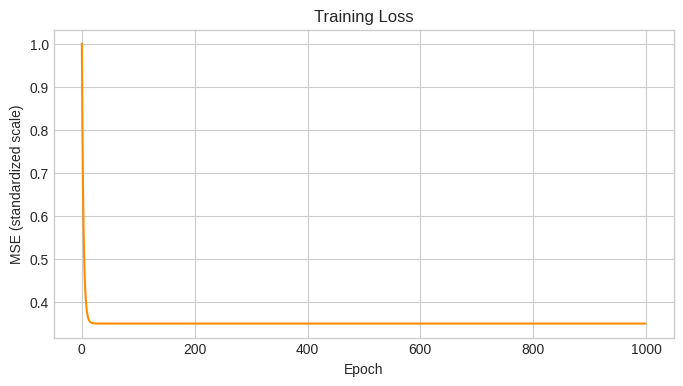

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('MSE (standardized scale)')
plt.title('Training Loss')
plt.show()

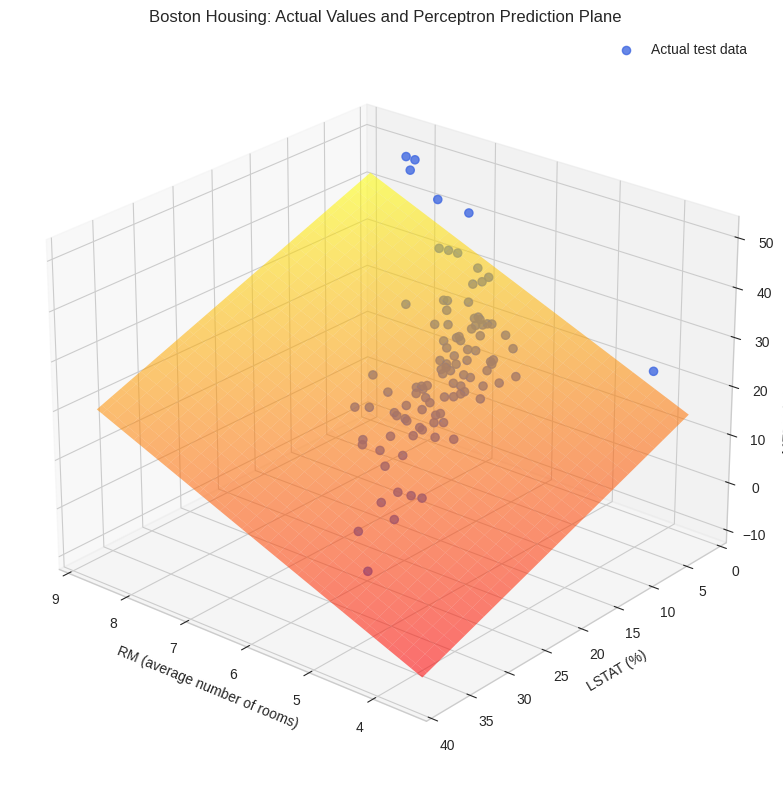

In [8]:
rm_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 60)
lstat_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), 60)
RM, LSTAT = np.meshgrid(rm_grid, lstat_grid)
grid = np.column_stack([RM.ravel(), LSTAT.ravel()])

grid_s = x_scaler.transform(grid)
surface_s = model.predict(grid_s)
Y_PRED = y_scaler.inverse_transform(surface_s).reshape(RM.shape)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test[:, 0], X_test[:, 1], y_test.ravel(),
           c='royalblue', s=35, alpha=0.8, label='Actual test data')
ax.plot_surface(RM, LSTAT, Y_PRED, cmap='autumn', alpha=0.55, edgecolor='none')

ax.set_xlabel('RM (average number of rooms)')
ax.set_ylabel('LSTAT (%)')
ax.set_zlabel('MEDV (price in $1000s)')
ax.set_title('Boston Housing: Actual Values and Perceptron Prediction Plane')
ax.legend()
ax.view_init(elev=25, azim=130)
plt.tight_layout()
plt.show()